# scVI-only single-cell analysis notebook

This notebook performs a clean **scVI-only** workflow for single-cell RNA-seq data.

It does **not** compare against PCA or scGPT. The purpose is to understand and document what scVI does on one dataset:

1. Load an annotated single-cell dataset.
2. Standardize metadata.
3. Perform QC and preprocessing.
4. Preserve raw counts for scVI.
5. Train an scVI model.
6. Extract the scVI latent representation.
7. Build a neighbor graph using `X_scvi`.
8. Run UMAP and Leiden clustering.
9. Evaluate clusters against independent labels, if available.
10. Generate saved outputs and a small report.

Important conceptual rule:

> scVI should be trained on raw count data, not log-normalized data.

## 0. Setup

Run this notebook from the project root if possible.

Expected project structure:

```text
sc-embedding-benchmark/
├── data/
│   ├── raw/
│   └── processed/
├── models/
├── reports/
└── notebooks/
```

In [1]:
from pathlib import Path
import os
import json
import warnings

import numpy as np
import pandas as pd
import scipy.sparse as sp

import scanpy as sc
import anndata as ad
import scvi

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

warnings.filterwarnings("default")

print("scanpy:", sc.__version__)
print("scvi-tools:", scvi.__version__)
print("Current working directory:", os.getcwd())

c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\docrep\decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


scanpy: 1.11.5
scvi-tools: 1.2.1
Current working directory: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\notebooks


C:\Users\acer\AppData\Local\Temp\ipykernel_31152\4195685934.py:22: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)


## 1. Configuration

For the first clean scVI run, use `scvi.data.pbmc_dataset()`.

This dataset is useful because it normally includes:

- `adata.obs["labels"]`: independent biological label categories.
- `adata.obs["batch"]`: batch information.

If you later want to use your own `.h5ad`, set:

```python
"input_mode": "h5ad"
"input_h5ad": "path/to/file.h5ad"
```

In [2]:
# Resolve project root robustly.
# If you opened the notebook from /notebooks, this moves paths one level up.
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"

for d in [RAW_DIR, PROCESSED_DIR, MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # Dataset options:
    # "scvi_pbmc_dataset" or "h5ad"
    "input_mode": "scvi_pbmc_dataset",
    "input_h5ad": None,

    "dataset_name": "pbmc_scvi_dataset_scvi_only",

    # Metadata keys in the loaded object.
    # For scvi.data.pbmc_dataset(), these should usually be:
    "label_key": "labels",
    "batch_key": "batch",

    # QC filtering.
    "min_genes_per_cell": 200,
    "max_genes_per_cell": None,
    "min_cells_per_gene": 3,
    "max_pct_mt": 20,

    # Normalization/HVG settings.
    # Normalized/log data is used for HVG selection and plotting.
    # Raw counts are saved separately for scVI.
    "target_sum": 1e4,
    "n_top_hvgs": 2000,
    "hvg_flavor": "seurat",

    # scVI model settings.
    "n_latent": 10,
    "n_hidden": 128,
    "n_layers": 2,
    "max_epochs": 100,
    "random_seed": 0,

    # Graph/UMAP/clustering settings.
    "n_neighbors": 15,
    "leiden_resolution": 0.5,
}

print(json.dumps(CONFIG, indent=2))
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)

{
  "input_mode": "scvi_pbmc_dataset",
  "input_h5ad": null,
  "dataset_name": "pbmc_scvi_dataset_scvi_only",
  "label_key": "labels",
  "batch_key": "batch",
  "min_genes_per_cell": 200,
  "max_genes_per_cell": null,
  "min_cells_per_gene": 3,
  "max_pct_mt": 20,
  "target_sum": 10000.0,
  "n_top_hvgs": 2000,
  "hvg_flavor": "seurat",
  "n_latent": 10,
  "n_hidden": 128,
  "n_layers": 2,
  "max_epochs": 100,
  "random_seed": 0,
  "n_neighbors": 15,
  "leiden_resolution": 0.5
}
PROJECT_ROOT: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark
RAW_DIR: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\raw


## 2. Load dataset

This cell loads the dataset and prints the available metadata.

If `scvi.data.pbmc_dataset()` fails because of a corrupted partial download, delete the relevant raw data folder and rerun. If you use an `.h5ad`, make sure the file contains raw counts or a counts layer.

In [3]:
def load_dataset(config):
    mode = config["input_mode"]

    if mode == "scvi_pbmc_dataset":
        adata = scvi.data.pbmc_dataset(
            save_path=str(RAW_DIR),
            remove_extracted_data=False,
        )

    elif mode == "h5ad":
        if config["input_h5ad"] is None:
            raise ValueError("CONFIG['input_h5ad'] must be set when input_mode='h5ad'.")
        adata = sc.read_h5ad(config["input_h5ad"])

    else:
        raise ValueError(f"Unknown input_mode: {mode}")

    adata.var_names_make_unique()
    return adata


adata = load_dataset(CONFIG)

print(adata)
print("\nobs columns:")
print(list(adata.obs.columns))
print("\nvar columns:")
print(list(adata.var.columns))
print("\nfirst var_names:")
print(list(adata.var_names[:10]))

display(adata.obs.head())
display(adata.var.head())

INFO     Downloading file at                                                                                       
         e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\raw\gene_info_pbmc.csv             
Downloading...: 909it [00:00, 5736.61it/s]                           
INFO     Downloading file at                                                                                       
         e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\raw\pbmc_metadata.pickle           
Downloading...: 4001it [00:00, 6922.64it/s]                            
INFO     Downloading file at                                                                                       
         e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\raw\pbmc8k\filtered_gene_bc_matrice
         s.tar.gz                                                                                                  
Downloading...: 37559it [00:04, 8833.34it/s]  

c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


INFO     Downloading file at                                                                                       
         e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\raw\pbmc4k\filtered_gene_bc_matrice
         s.tar.gz                                                                                                  
Downloading...: 100%|██████████| 18424/18424.0 [00:02<00:00, 8911.39it/s]
INFO     Extracting tar file                                                                                       


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\merge.py:847: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  concat_indices = concat_indices.str.cat(label_col.map(str), sep=index_unique)
c:\

AnnData object with n_obs × n_vars = 11990 × 3346
    obs: 'n_counts', 'batch', 'labels', 'str_labels'
    var: 'gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts'
    uns: 'cell_types'
    obsm: 'design', 'raw_qc', 'normalized_qc', 'qc_pc'

obs columns:
['n_counts', 'batch', 'labels', 'str_labels']

var columns:
['gene_symbols', 'n_counts-0', 'n_counts-1', 'n_counts']

first var_names:
['ENSG00000188976', 'ENSG00000187608', 'ENSG00000149527', 'ENSG00000157881', 'ENSG00000157873', 'ENSG00000130764', 'ENSG00000198912', 'ENSG00000162408', 'ENSG00000204859', 'ENSG00000162413']


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


,n_counts,batch,labels,str_labels
AAACCTGAGCTAGTGG-1,4520.0,0,2,CD4 T cells
AAACCTGCACATTAGC-1,2788.0,0,2,CD4 T cells
AAACCTGCACTGTTAG-1,4667.0,0,1,CD14+ Monocytes
AAACCTGCATAGTAAG-1,4440.0,0,1,CD14+ Monocytes
AAACCTGCATGAACCT-1,3224.0,0,3,CD8 T cells


,gene_symbols,n_counts-0,n_counts-1,n_counts
ENSG00000188976,NOC2L,1477.0,718.0,2135.0
ENSG00000187608,ISG15,4014.0,1888.0,5705.0
ENSG00000149527,PLCH2,121.0,41.0,157.0
ENSG00000157881,PANK4,224.0,107.0,326.0
ENSG00000157873,TNFRSF14,3639.0,1683.0,5193.0


## 3. Standardize metadata

We create standard columns used throughout the notebook:

- `adata.obs["cell_type"]`: independent biological labels, if available.
- `adata.obs["batch"]`: batch labels, if available.

If no labels exist, biological metrics are skipped.  
If no batch exists, batch diagnostics are skipped.

In [16]:
label_key = CONFIG["label_key"]
batch_key = CONFIG["batch_key"]

# Standardize biological labels.
if label_key is not None and label_key in adata.obs.columns:
    adata.obs["cell_type"] = adata.obs[label_key].astype("category")
    HAS_LABELS = adata.obs["cell_type"].nunique() > 1
else:
    adata.obs["cell_type"] = "unknown"
    adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")
    HAS_LABELS = False

# Standardize batch labels.
if batch_key is not None and batch_key in adata.obs.columns:
    adata.obs["batch"] = adata.obs[batch_key].astype("category")
    HAS_BATCH = adata.obs["batch"].nunique() > 1
else:
    adata.obs["batch"] = "batch_0"
    adata.obs["batch"] = adata.obs["batch"].astype("category")
    HAS_BATCH = False

print("HAS_LABELS:", HAS_LABELS)
print("HAS_BATCH:", HAS_BATCH)

print("\ncell_type distribution:")
print(adata.obs["cell_type"].value_counts())

print("\nbatch distribution:")
print(adata.obs["batch"].value_counts())

HAS_LABELS: True
HAS_BATCH: True

cell_type distribution:
cell_type
2    4995
1    2227
0    1621
3    1448
8     463
7     457
5     351
4     339
6      88
Name: count, dtype: int64

batch distribution:
batch
0    7981
1    4008
Name: count, dtype: int64


## 4. Basic QC metrics

We compute common QC features:

- `n_genes_by_counts`: number of detected genes per cell.
- `total_counts`: total expression counts per cell.
- `pct_counts_mt`: percent mitochondrial counts, if mitochondrial genes are identifiable.

Mitochondrial genes are detected using gene names starting with `MT-`.

,n_genes_by_counts,total_counts,pct_counts_mt
count,11989.000000,11989.000000,11989.0
mean,220.139878,546.109802,0.0
std,73.680315,105.393539,0.0
min,94.000000,291.457153,0.0
25%,172.000000,465.562988,0.0
50%,202.000000,528.389954,0.0
75%,244.000000,612.709900,0.0
max,835.000000,980.977966,0.0


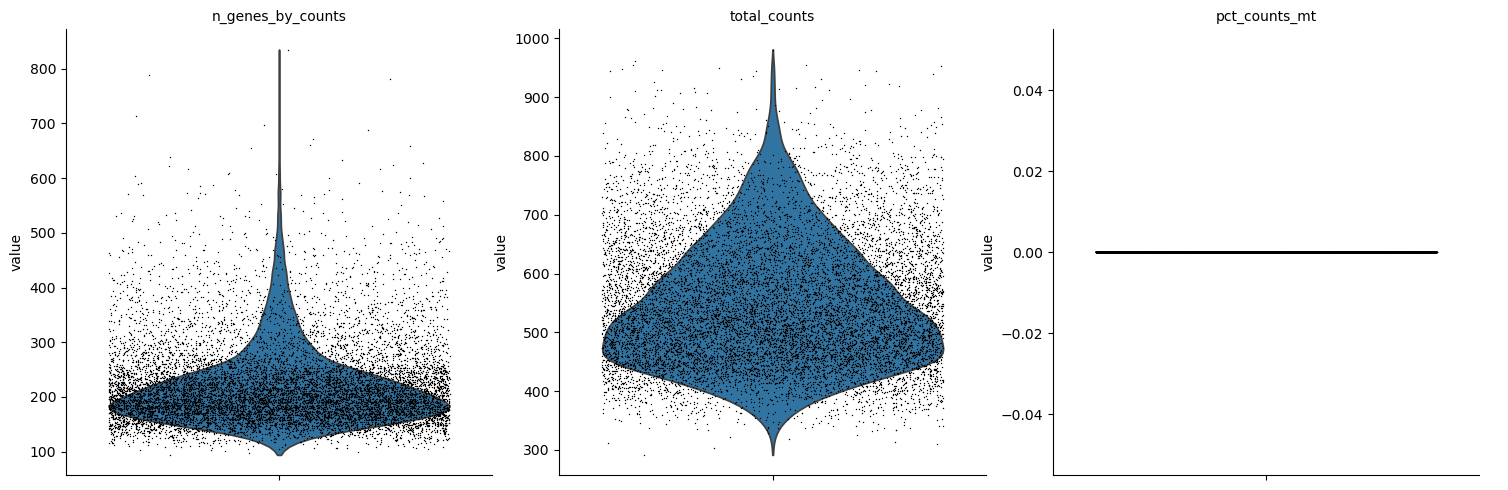

In [17]:
# Identify mitochondrial genes if gene symbols are in var_names.
adata.var["mt"] = adata.var_names.astype(str).str.upper().str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

qc_cols = ["n_genes_by_counts", "total_counts"]
if "pct_counts_mt" in adata.obs.columns:
    qc_cols.append("pct_counts_mt")

display(adata.obs[qc_cols].describe())

sc.pl.violin(
    adata,
    qc_cols,
    jitter=0.4,
    multi_panel=True,
    show=True,
)

## 5. Filter cells and genes

Filtering removes clearly low-quality cells and genes that are almost never detected.

These are conservative defaults:

- Remove cells with fewer than `min_genes_per_cell` detected genes.
- Optionally remove cells with more than `max_genes_per_cell` detected genes.
- Remove genes detected in fewer than `min_cells_per_gene` cells.
- Optionally remove cells with high mitochondrial percentage.

For a serious report, always document these thresholds.

In [18]:
print("Before filtering:", adata.shape)

# Cell filters.
sc.pp.filter_cells(
    adata,
    min_genes=CONFIG["min_genes_per_cell"],
)

if CONFIG["max_genes_per_cell"] is not None:
    sc.pp.filter_cells(
        adata,
        max_genes=CONFIG["max_genes_per_cell"],
    )

# Gene filter.
sc.pp.filter_genes(
    adata,
    min_cells=CONFIG["min_cells_per_gene"],
)

# Mitochondrial filter, only if mt genes were detected.
if adata.var["mt"].sum() > 0 and "pct_counts_mt" in adata.obs.columns:
    adata = adata[adata.obs["pct_counts_mt"] < CONFIG["max_pct_mt"]].copy()

print("After filtering:", adata.shape)

display(adata.obs[qc_cols].describe())

Before filtering: (11989, 2000)


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


After filtering: (6238, 2000)


,n_genes_by_counts,total_counts,pct_counts_mt
count,6238.000000,6238.000000,6238.0
mean,267.749599,620.758667,0.0
std,72.994058,86.872482,0.0
min,200.000000,447.530487,0.0
25%,218.000000,556.727982,0.0
50%,242.000000,608.117584,0.0
75%,292.000000,673.720383,0.0
max,835.000000,980.977966,0.0


## 6. Preserve raw counts

This is the most important scVI-specific step.

`adata.X` at this point should contain raw count-like values.  
We save it into:

```python
adata.layers["counts"]
```

Later, `adata.X` will be normalized and log-transformed for HVG selection and plotting, but scVI will still use the raw counts layer.

In [19]:
adata.layers["counts"] = adata.X.copy()

# Validate counts layer.
assert "counts" in adata.layers, "Missing counts layer."
assert adata.layers["counts"].shape == adata.X.shape, "Counts layer shape mismatch."

# Basic count sanity check.
counts = adata.layers["counts"]
if sp.issparse(counts):
    min_count = counts.data.min() if counts.data.size > 0 else 0
    max_count = counts.data.max() if counts.data.size > 0 else 0
else:
    min_count = np.min(counts)
    max_count = np.max(counts)

print("counts layer saved.")
print("min nonzero/raw value:", min_count)
print("max value:", max_count)

counts layer saved.
min nonzero/raw value: 0.6278571
max value: 7.476671


## 7. Normalize/log-transform for HVG selection and plotting

scVI will use `adata.layers["counts"]`.

However, for HVG selection, plotting, and QC exploration, we keep a normalized/log-transformed version in `adata.X`.

Steps:

1. Normalize each cell to the same total count.
2. Apply `log1p`, meaning `log(1 + x)`.

In [20]:
sc.pp.normalize_total(
    adata,
    target_sum=CONFIG["target_sum"],
)

sc.pp.log1p(adata)

# Save full normalized/log data before HVG subsetting.
adata.raw = adata.copy()

print("adata.X is now normalized/log-transformed.")
print("adata.layers['counts'] still contains raw counts.")

adata.X is now normalized/log-transformed.
adata.layers['counts'] still contains raw counts.


## 8. Highly variable genes

We select highly variable genes to reduce noise and speed up modeling.

This notebook uses a simple, robust Scanpy HVG workflow.  
For the first scVI-only run, we do **not** use batch-aware HVG selection. scVI itself will model batch using `batch_key`.

If the dataset has fewer genes than the requested number of HVGs, the notebook automatically uses the available number.

Selecting 2000 highly variable genes from 2000 genes.
highly_variable
True    2000
Name: count, dtype: int64


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


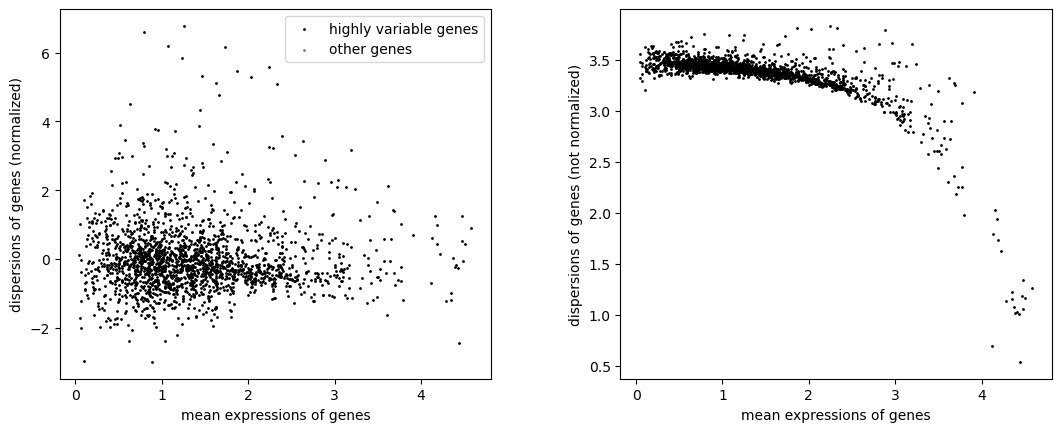

After HVG subsetting: (6238, 2000)


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\anndata\_core\anndata.py:1118: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [21]:
n_top_hvgs = min(CONFIG["n_top_hvgs"], adata.n_vars)

print(f"Selecting {n_top_hvgs} highly variable genes from {adata.n_vars} genes.")

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=n_top_hvgs,
    flavor=CONFIG["hvg_flavor"],
)

print(adata.var["highly_variable"].value_counts())

sc.pl.highly_variable_genes(
    adata,
    show=True,
)

adata = adata[:, adata.var["highly_variable"]].copy()

# Ensure counts layer survived after HVG subsetting.
assert "counts" in adata.layers
assert adata.layers["counts"].shape == adata.X.shape

print("After HVG subsetting:", adata.shape)

## 9. Validate AnnData before scVI

Before training, confirm:

- raw counts layer exists,
- labels and batch columns exist,
- no empty matrix,
- no NaN/Inf values in the counts layer.

In [22]:
def validate_for_scvi(adata):
    assert adata.n_obs > 0, "No cells."
    assert adata.n_vars > 0, "No genes."
    assert "counts" in adata.layers, "Missing adata.layers['counts']."
    assert "batch" in adata.obs.columns, "Missing adata.obs['batch']."
    assert "cell_type" in adata.obs.columns, "Missing adata.obs['cell_type']."

    X = adata.layers["counts"]

    if sp.issparse(X):
        if np.isnan(X.data).any():
            raise ValueError("counts layer contains NaN values.")
        if np.isinf(X.data).any():
            raise ValueError("counts layer contains Inf values.")
        n_counts_per_cell = np.asarray(X.sum(axis=1)).ravel()
    else:
        if np.isnan(X).any():
            raise ValueError("counts layer contains NaN values.")
        if np.isinf(X).any():
            raise ValueError("counts layer contains Inf values.")
        n_counts_per_cell = np.asarray(X.sum(axis=1)).ravel()

    if (n_counts_per_cell == 0).any():
        raise ValueError("Some cells have zero total counts after preprocessing.")

    print("scVI validation passed.")
    print("Cells:", adata.n_obs)
    print("Genes:", adata.n_vars)
    print("Batches:", adata.obs["batch"].nunique())
    print("Cell-type labels:", adata.obs["cell_type"].nunique())


validate_for_scvi(adata)

scVI validation passed.
Cells: 6238
Genes: 2000
Batches: 2
Cell-type labels: 9


## 10. Register AnnData for scVI

`setup_anndata()` tells scVI where the raw counts and batch labels are stored.

Here:

- `layer="counts"` means scVI trains on raw counts.
- `batch_key="batch"` means scVI knows which cells came from which batch.

This does not train the model yet. It only registers the data structure.

In [23]:
# scvi.settings.seed = CONFIG["random_seed"]

# scvi.model.SCVI.setup_anndata(
#     adata,
#     layer="counts",
#     batch_key="batch",
# )

# scvi.model.SCVI.view_anndata_setup(adata)
import rich.pretty


scvi.settings.seed = CONFIG["random_seed"]

scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="batch",
)

model = scvi.model.SCVI(
    adata,
    n_latent=CONFIG["n_latent"],
    n_hidden=CONFIG["n_hidden"],
    n_layers=CONFIG["n_layers"],
)

model.view_anndata_setup()

Seed set to 0


c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scvi\data\fields\_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.2.1.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': 'counts',
│   'batch_key': 'batch',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   2   │
│         n_cells          │ 6238  │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 2000  │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │  adata.layers['counts']   │
│    batch     │ adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['batch'] │     0      │          0          │
│                    │     1      │          1          │
└────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

## 11. Initialize and train the scVI model

scVI is a probabilistic deep generative model.

Important parameters:

- `n_latent`: dimensionality of the learned latent space.
- `n_hidden`: hidden units in the neural network.
- `n_layers`: number of hidden layers.

The output we care about is the latent representation:

```python
adata.obsm["X_scvi"]
```

In [24]:
model = scvi.model.SCVI(
    adata,
    n_latent=CONFIG["n_latent"],
    n_hidden=CONFIG["n_hidden"],
    n_layers=CONFIG["n_layers"],
)

print(model)

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [25]:
model.train(
    max_epochs=CONFIG["max_epochs"],
)

# Display training history if available.
try:
    display(model.history.tail())
except Exception as e:
    print("Could not display model.history:", e)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 1/100:   0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scvi\module\_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scvi\module\_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 2/100:   1%|          | 1/100 [00:03<05:39,  3.43s/it, v_num=1, train_loss_step=1.08e+3, train_loss_epoch=1.18e+3]

c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scvi\module\_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scvi\module\_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


...

Epoch 100/100:  99%|█████████▉| 99/100 [04:04<00:02,  2.37s/it, v_num=1, train_loss_step=956, train_loss_epoch=942]

c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scvi\module\_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
c:\Users\acer\anaconda3\envs\sc-embedding-benchmark\lib\site-packages\scvi\module\_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 100/100: 100%|██████████| 100/100 [04:06<00:00,  2.37s/it, v_num=1, train_loss_step=937, train_loss_epoch=942]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [04:06<00:00,  2.47s/it, v_num=1, train_loss_step=937, train_loss_epoch=942]
Could not display model.history: 'dict' object has no attribute 'tail'


## 12. Extract scVI latent representation

The latent space is the main result of scVI.

Each cell receives a compact vector representation, usually with `n_latent` dimensions.

In [26]:
adata.obsm["X_scvi"] = model.get_latent_representation()

print("X_scvi shape:", adata.obsm["X_scvi"].shape)
assert adata.obsm["X_scvi"].shape[0] == adata.n_obs
assert adata.obsm["X_scvi"].shape[1] == CONFIG["n_latent"]

X_scvi shape: (6238, 10)


## 13. Neighbor graph, UMAP, and Leiden clustering using scVI space

Now we analyze the learned scVI latent space.

The chain is:

```text
X_scvi
→ neighbor graph
→ UMAP
→ Leiden clusters
```

This is analogous to a PCA workflow, but the graph is built from the scVI latent representation.

In [27]:
sc.pp.neighbors(
    adata,
    n_neighbors=CONFIG["n_neighbors"],
    use_rep="X_scvi",
)

sc.tl.umap(
    adata,
    random_state=CONFIG["random_seed"],
)

adata.obsm["X_umap_scvi"] = adata.obsm["X_umap"].copy()

sc.tl.leiden(
    adata,
    resolution=CONFIG["leiden_resolution"],
    key_added="leiden_scvi",
    random_state=CONFIG["random_seed"],
)

print(adata.obs["leiden_scvi"].value_counts().sort_index())

C:\Users\acer\AppData\Local\Temp\ipykernel_31152\2844793632.py:14: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


leiden_scvi
0     1605
1      982
2      956
3      795
4      519
5      370
6      326
7      311
8      251
9       98
10      25
Name: count, dtype: int64


## 14. Visualize scVI UMAP

Interpretation:

- `cell_type`: whether independent labels form coherent regions.
- `batch`: whether batches are mixed or separated.
- `leiden_scvi`: clusters discovered from the scVI neighbor graph.
- QC metrics: whether technical covariates dominate the embedding.

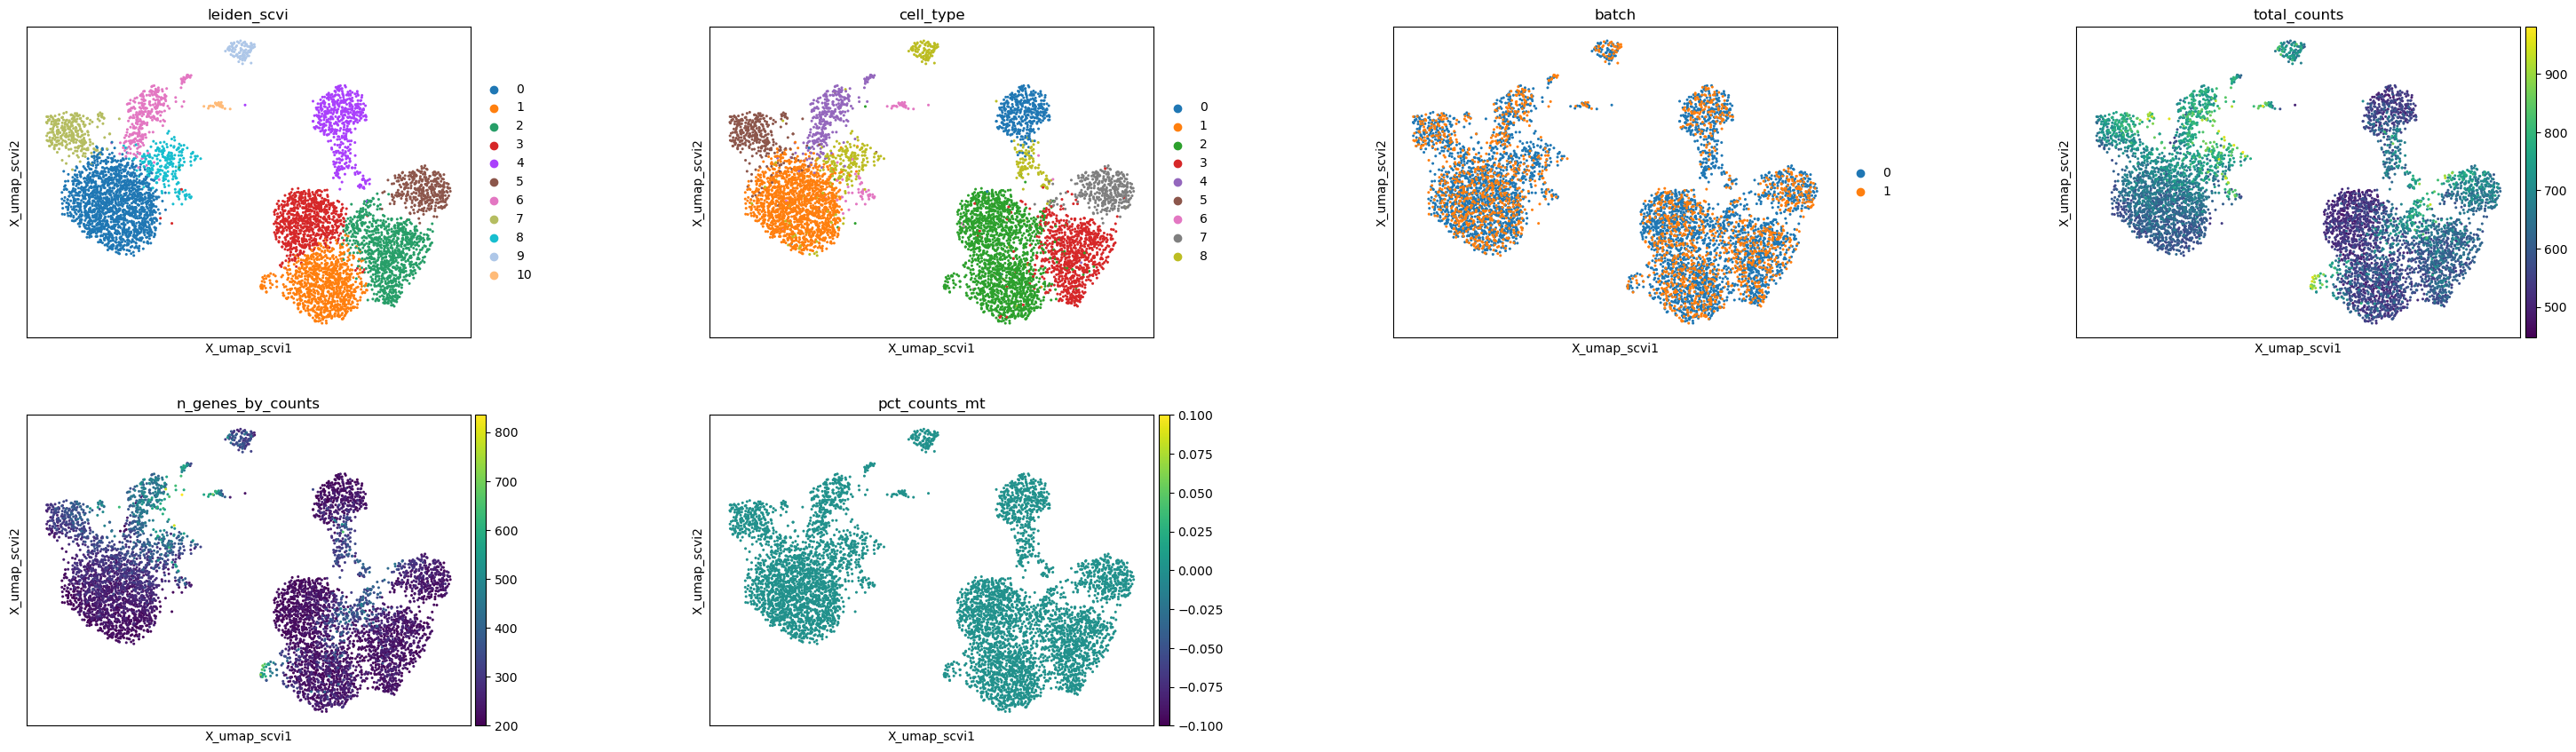

In [28]:
plot_colors = ["leiden_scvi"]

if HAS_LABELS:
    plot_colors.append("cell_type")

if HAS_BATCH:
    plot_colors.append("batch")

for col in ["total_counts", "n_genes_by_counts", "pct_counts_mt"]:
    if col in adata.obs.columns:
        plot_colors.append(col)

sc.pl.embedding(
    adata,
    basis="X_umap_scvi",
    color=plot_colors,
    wspace=0.4,
    show=True,
)

## 15. Biological evaluation, if independent labels exist

These metrics are valid only if `cell_type` comes from the dataset or an external source, not from scVI/Leiden clusters.

Metrics:

- **ARI**: agreement between Leiden clusters and independent labels.
- **NMI**: information overlap between clusters and labels.
- **Silhouette**: separation of cell-type labels in scVI latent space.

In [29]:
metrics = {}

if HAS_LABELS:
    y_true = adata.obs["cell_type"].astype(str)
    y_pred = adata.obs["leiden_scvi"].astype(str)

    metrics["ARI_cell_type"] = adjusted_rand_score(y_true, y_pred)
    metrics["NMI_cell_type"] = normalized_mutual_info_score(y_true, y_pred)

    # Silhouette needs at least 2 labels and fewer labels than cells.
    if y_true.nunique() > 1 and y_true.nunique() < adata.n_obs:
        metrics["silhouette_cell_type_X_scvi"] = silhouette_score(
            adata.obsm["X_scvi"],
            y_true,
        )

    print("Biological metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
else:
    print("No independent labels available. Skipping biological metrics.")

Biological metrics:
ARI_cell_type: 0.7226
NMI_cell_type: 0.7918
silhouette_cell_type_X_scvi: 0.1317


## 16. Batch diagnostics, if batches exist

For batch-aware datasets, inspect whether batches are mixed in the scVI latent space.

A simple diagnostic is silhouette by batch:

- High batch silhouette: batches are separated.
- Low or near-zero batch silhouette: batches are more mixed.

This is not a complete integration benchmark, but it is useful as a first diagnostic.

Batch diagnostics:
Batch counts:
batch
0    4335
1    1903
Name: count, dtype: int64

Batch silhouette:
0.004013729747384787


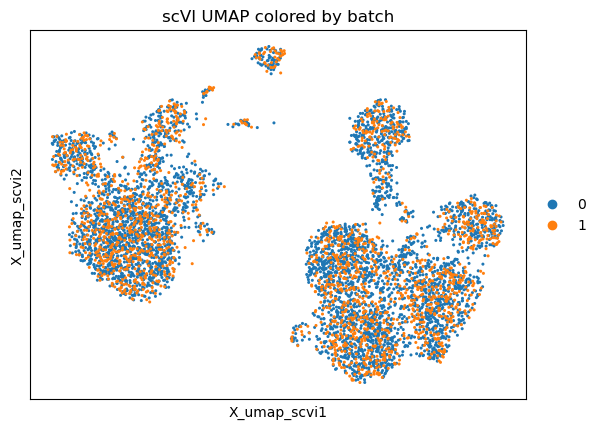

In [30]:
if HAS_BATCH:
    y_batch = adata.obs["batch"].astype(str)

    if y_batch.nunique() > 1 and y_batch.nunique() < adata.n_obs:
        metrics["silhouette_batch_X_scvi"] = silhouette_score(
            adata.obsm["X_scvi"],
            y_batch,
        )

    print("Batch diagnostics:")
    print("Batch counts:")
    print(adata.obs["batch"].value_counts())

    print("\nBatch silhouette:")
    print(metrics.get("silhouette_batch_X_scvi"))

    sc.pl.embedding(
        adata,
        basis="X_umap_scvi",
        color=["batch"],
        title="scVI UMAP colored by batch",
        show=True,
    )
else:
    print("Only one batch available. Skipping batch diagnostics.")

## 17. Cluster purity table, if labels exist

This table shows the distribution of independent cell-type labels inside each scVI Leiden cluster.

Rows sum to 1.

In [31]:
if HAS_LABELS:
    purity = pd.crosstab(
        adata.obs["leiden_scvi"],
        adata.obs["cell_type"],
        normalize="index",
    )
    display(purity)
else:
    purity = None
    print("No labels available. Skipping purity table.")

cell_type,0,1,2,3,4,5,6,7,8
leiden_scvi,,,,,,,,,
0,0.000623,0.940187,0.001246,0.000000,0.008100,0.019938,0.006854,0.000000,0.023053
1,0.001018,0.003055,0.955193,0.037678,0.000000,0.000000,0.002037,0.000000,0.001018
2,0.000000,0.000000,0.110879,0.865063,0.001046,0.001046,0.001046,0.018828,0.002092
3,0.001258,0.001258,0.969811,0.020126,0.000000,0.000000,0.002516,0.000000,0.005031
4,0.770713,0.000000,0.003854,0.001927,0.000000,0.000000,0.005780,0.003854,0.213873
5,0.000000,0.000000,0.000000,0.021622,0.000000,0.000000,0.000000,0.975676,0.002703
6,0.003067,0.009202,0.003067,0.000000,0.969325,0.000000,0.006135,0.000000,0.009202
7,0.000000,0.028939,0.000000,0.000000,0.000000,0.967846,0.000000,0.000000,0.003215
8,0.003984,0.067729,0.000000,0.000000,0.011952,0.019920,0.135458,0.000000,0.760956


## 18. Save outputs

This saves:

- processed AnnData object with `X_scvi`, UMAP, and clusters,
- trained scVI model,
- metrics CSV,
- metadata summaries,
- a small deterministic Markdown report.

In [32]:
dataset_name = CONFIG["dataset_name"]
dataset_report_dir = REPORT_DIR / dataset_name
dataset_model_dir = MODEL_DIR / dataset_name / "scvi_model"

dataset_report_dir.mkdir(parents=True, exist_ok=True)
dataset_model_dir.parent.mkdir(parents=True, exist_ok=True)

# Save AnnData.
adata_out = PROCESSED_DIR / f"{dataset_name}.h5ad"
adata.write(adata_out)

# Save scVI model.
model.save(
    str(dataset_model_dir),
    overwrite=True,
)

# Save metrics.
metrics_df = pd.DataFrame(
    [{"method": "scVI", **metrics}]
)
metrics_path = dataset_report_dir / "scvi_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

# Save label and batch summaries.
adata.obs["cell_type"].value_counts().rename_axis("cell_type").reset_index(name="n_cells").to_csv(
    dataset_report_dir / "cell_type_distribution.csv",
    index=False,
)

adata.obs["batch"].value_counts().rename_axis("batch").reset_index(name="n_cells").to_csv(
    dataset_report_dir / "batch_distribution.csv",
    index=False,
)

qc_summary = adata.obs[[c for c in qc_cols if c in adata.obs.columns]].describe().T
qc_summary.to_csv(dataset_report_dir / "qc_summary.csv")

print("Saved AnnData:", adata_out)
print("Saved model:", dataset_model_dir)
print("Saved metrics:", metrics_path)

display(metrics_df)

Saved AnnData: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\data\processed\pbmc_scvi_dataset_scvi_only.h5ad
Saved model: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\models\pbmc_scvi_dataset_scvi_only\scvi_model
Saved metrics: e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\reports\pbmc_scvi_dataset_scvi_only\scvi_metrics.csv


,method,ARI_cell_type,NMI_cell_type,silhouette_cell_type_X_scvi,silhouette_batch_X_scvi
0,scVI,0.722639,0.7918,0.131655,0.004014


## 19. Deterministic text report

This report is not generated by an LLM. It is a simple reproducible summary of the run.

In [33]:
report_lines = [
    f"# scVI-only report: {dataset_name}",
    "",
    "## Dataset",
    f"- Cells after preprocessing: {adata.n_obs}",
    f"- HVGs used: {adata.n_vars}",
    f"- Labels available: {HAS_LABELS}",
    f"- Batches available: {HAS_BATCH}",
    "",
    "## scVI configuration",
    f"- n_latent: {CONFIG['n_latent']}",
    f"- n_hidden: {CONFIG['n_hidden']}",
    f"- n_layers: {CONFIG['n_layers']}",
    f"- max_epochs: {CONFIG['max_epochs']}",
    f"- batch_key: batch",
    f"- count layer: adata.layers['counts']",
    "",
    "## Metrics",
]

if len(metrics) == 0:
    report_lines.append("- No metrics were computed.")
else:
    for k, v in metrics.items():
        report_lines.append(f"- {k}: {v:.4f}")

report_lines.extend([
    "",
    "## Interpretation notes",
    "- The scVI latent space is stored in `adata.obsm['X_scvi']`.",
    "- The UMAP shown here is computed from the scVI neighbor graph.",
    "- Biological metrics are valid only if `cell_type` is independent of the clustering.",
    "- Batch silhouette is a simple diagnostic, not a complete integration benchmark.",
])

report_path = dataset_report_dir / "report.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print(report_path)
print("\n".join(report_lines))

e:\fields_of_study\bioinformatics\Projects\sc-embedding-benchmark\reports\pbmc_scvi_dataset_scvi_only\report.md
# scVI-only report: pbmc_scvi_dataset_scvi_only

## Dataset
- Cells after preprocessing: 6238
- HVGs used: 2000
- Labels available: True
- Batches available: True

## scVI configuration
- n_latent: 10
- n_hidden: 128
- n_layers: 2
- max_epochs: 100
- batch_key: batch
- count layer: adata.layers['counts']

## Metrics
- ARI_cell_type: 0.7226
- NMI_cell_type: 0.7918
- silhouette_cell_type_X_scvi: 0.1317
- silhouette_batch_X_scvi: 0.0040

## Interpretation notes
- The scVI latent space is stored in `adata.obsm['X_scvi']`.
- The UMAP shown here is computed from the scVI neighbor graph.
- Biological metrics are valid only if `cell_type` is independent of the clustering.
- Batch silhouette is a simple diagnostic, not a complete integration benchmark.


## 20. What to explain when presenting this notebook

Use this explanation:

> I trained scVI on raw single-cell count data stored in `adata.layers["counts"]`. Before training, I applied QC filtering and selected highly variable genes to reduce noise. I registered the AnnData object with `setup_anndata`, specifying the raw-count layer and the batch column. After training, I extracted the scVI latent representation into `adata.obsm["X_scvi"]`. I then built a nearest-neighbor graph in this latent space, ran UMAP for visualization, and used Leiden clustering to identify groups of transcriptionally similar cells. If independent cell-type labels were available, I evaluated the clustering using ARI, NMI, and silhouette. If batches were available, I inspected batch mixing using UMAP and batch silhouette.

Key conceptual distinction:

- PCA is a linear dimensionality reduction method.
- scVI is a probabilistic deep generative model trained on raw counts.
- The scVI latent space is designed to capture biological variation while modeling technical variation such as batch effects.